In [1]:
!git clone https://github.com/niaz1971/BOOK_CHAPTERS.git

Cloning into 'BOOK_CHAPTERS'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 41 (delta 9), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (41/41), 10.49 MiB | 9.73 MiB/s, done.
Resolving deltas: 100% (9/9), done.


In [2]:
cd BOOK_CHAPTERS/Empowering Smart Agriculture and Rural Sustainability Through EfficientNetV2 Pest Classification

/content/BOOK_CHAPTERS/Empowering Smart Agriculture and Rural Sustainability Through EfficientNetV2 Pest Classification


In [3]:
!ls

kaggle.json


In [4]:
!pip install lime kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d vencerlanz09/agricultural-pests-image-dataset

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=e2a598a849f5bbba47873634156a215f0cc6fd7d24c186eade43c5f324268316
  Stored in directory: /root/.cache/pip/wheels/7c/04/5c/157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime
Dataset URL: https://www.kaggle.com/datasets/vencerlanz09/agricultural-pests-image-dataset
License(s): copyright-authors
100% 102M/102M [00:05<00:00, 18.1MB/s]



In [5]:
!ls

agricultural-pests-image-dataset.zip  kaggle.json


In [6]:
!unzip -q agricultural-pests-image-dataset.zip
!rm agricultural-pests-image-dataset.zip
!rm kaggle.json

In [7]:
!ls

ants  beetle	    earthworms	grasshopper  slug   wasp
bees  catterpillar  earwig	moth	     snail  weevil


In [8]:
# Basic Libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
import itertools
import random
import PIL
from PIL import UnidentifiedImageError
from IPython.display import HTML

# visualization libraries
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
import seaborn as sns

# Tensorflow Libraries
from tensorflow import keras
from tensorflow.keras import layers,models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import Callback, EarlyStopping,ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model
#from tensorflow.keras.layers.experimental import preprocessing

# System libraries
from pathlib import Path
import os.path

# Metrics
from sklearn.metrics import classification_report, confusion_matrix

sns.set(style='darkgrid')

In [9]:
# Seed Everything to reproduce results for future use cases
def seed_everything(seed=42):
    # Seed value for TensorFlow
    tf.random.set_seed(seed)

    # Seed value for NumPy
    np.random.seed(seed)

    # Seed value for Python's random library
    random.seed(seed)

    # Force TensorFlow to use single thread (optional for reproducibility)
    session_conf = tf.compat.v1.ConfigProto(
        intra_op_parallelism_threads=1,
        inter_op_parallelism_threads=1
    )

    # Ensure reproducibility with TensorFlow 2.x
    tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)

# Call the function to apply the seed settings
seed_everything()

In [10]:
# helper functions
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py

# Import series of helper functions
from helper_functions import create_tensorboard_callback, plot_loss_curves, unzip_data, compare_historys, walk_through_dir, pred_and_plot

--2026-08-25 15:37:20--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-08-25 15:37:20 (174 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [11]:
# insect harmfulness & action recommendations
insect_action_guide = {
    "ants": {"harmfulness": "Moderate", "recommendation": "Monitor colony activity; use bait if crop damage is observed."},
    "bees": {"harmfulness": "Beneficial", "recommendation": "No action needed. Bees support pollination."},
    "beetle": {"harmfulness": "Harmful", "recommendation": "Inspect plants and apply pesticide if necessary."},
    "catterpillar": {"harmfulness": "Harmful", "recommendation": "Use biological controls like Bacillus thuringiensis (Bt)."},
    "earthworms": {"harmfulness": "Beneficial", "recommendation": "No action needed. They improve soil health."},
    "earwig": {"harmfulness": "Neutral", "recommendation": "Control only if populations become invasive."},
    "grasshopper": {"harmfulness": "Harmful", "recommendation": "Use targeted insecticides or encourage natural predators."},
    "moth": {"harmfulness": "Moderate", "recommendation": "Monitor regularly; use pheromone traps if needed."},
    "slug": {"harmfulness": "Harmful", "recommendation": "Remove manually or use copper barriers."},
    "snail": {"harmfulness": "Moderate", "recommendation": "Hand-pick or use eco-friendly traps."},
    "wasp": {"harmfulness": "Mixed", "recommendation": "Only control if nests are near human activity."},
    "weevil": {"harmfulness": "Harmful", "recommendation": "Apply crop rotation and use insecticides where necessary."}
}

# Data Preprocessing

In [12]:
BATCH_SIZE = 32
TARGET_SIZE = (224, 224)

In [13]:
!mkdir agricultural-pests-image-dataset

In [14]:
!cp -r ants earthworms moth snail bees earwig wasp beetle grasshopper weevil agricultural-pests-image-dataset/

In [15]:
import shutil

folders_to_delete = [
    'catterpillar',
    'slug',
    'ants',
    'earthworms',
    'moth',
    'snail',
    'bees',
    'earwig',
    'wasp',
    'beetle',
    'grasshopper',
    'weevil'
]

for folder in folders_to_delete:
    try:
        shutil.rmtree(folder)
        print(f"Successfully deleted: {folder}")
    except FileNotFoundError:
        print(f"Folder not found: {folder}")

Successfully deleted: catterpillar
Successfully deleted: slug
Successfully deleted: ants
Successfully deleted: earthworms
Successfully deleted: moth
Successfully deleted: snail
Successfully deleted: bees
Successfully deleted: earwig
Successfully deleted: wasp
Successfully deleted: beetle
Successfully deleted: grasshopper
Successfully deleted: weevil


In [16]:
# Walk through each directory
dataset = "agricultural-pests-image-dataset"
walk_through_dir(dataset)

There are 10 directories and 0 images in 'agricultural-pests-image-dataset'.
There are 0 directories and 499 images in 'agricultural-pests-image-dataset/ants'.
There are 0 directories and 500 images in 'agricultural-pests-image-dataset/snail'.
There are 0 directories and 466 images in 'agricultural-pests-image-dataset/earwig'.
There are 0 directories and 485 images in 'agricultural-pests-image-dataset/weevil'.
There are 0 directories and 497 images in 'agricultural-pests-image-dataset/moth'.
There are 0 directories and 498 images in 'agricultural-pests-image-dataset/wasp'.
There are 0 directories and 500 images in 'agricultural-pests-image-dataset/bees'.
There are 0 directories and 416 images in 'agricultural-pests-image-dataset/beetle'.
There are 0 directories and 485 images in 'agricultural-pests-image-dataset/grasshopper'.
There are 0 directories and 323 images in 'agricultural-pests-image-dataset/earthworms'.


## Placing data into a Dataframe
<p style="font-size:20px; font-family:verdana; line-height: 1.7em">
The first column, <b>filepaths</b>, stores the location of each image file. The second column, <b>labels</b>, holds the corresponding class name for each image based on its file path.
</p>

In [17]:
# Convert image paths and corresponding labels into a structured DataFrame
def convert_path_to_df(dataset):
    image_dir = Path(dataset)  # Create a Path object from the dataset directory

    # Collect image file paths with common extensions
    filepaths = list(image_dir.glob(r'**/*.JPG')) + \
                list(image_dir.glob(r'**/*.jpg')) + \
                list(image_dir.glob(r'**/*.png')) + \
                list(image_dir.glob(r'**/*.PNG'))

    # Extract labels from folder names (i.e., the parent directory of each image)
    labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))

    # Convert file paths and labels to pandas Series
    filepaths = pd.Series(filepaths, name='Filepath').astype(str)
    labels = pd.Series(labels, name='Label')

    # Combine into a single DataFrame
    image_df = pd.concat([filepaths, labels], axis=1)
    return image_df

# Apply the function to your dataset directory
image_df = convert_path_to_df(dataset)

/tmp/ipykernel_543/17306933.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, alpha=0.8, palette='rocket')


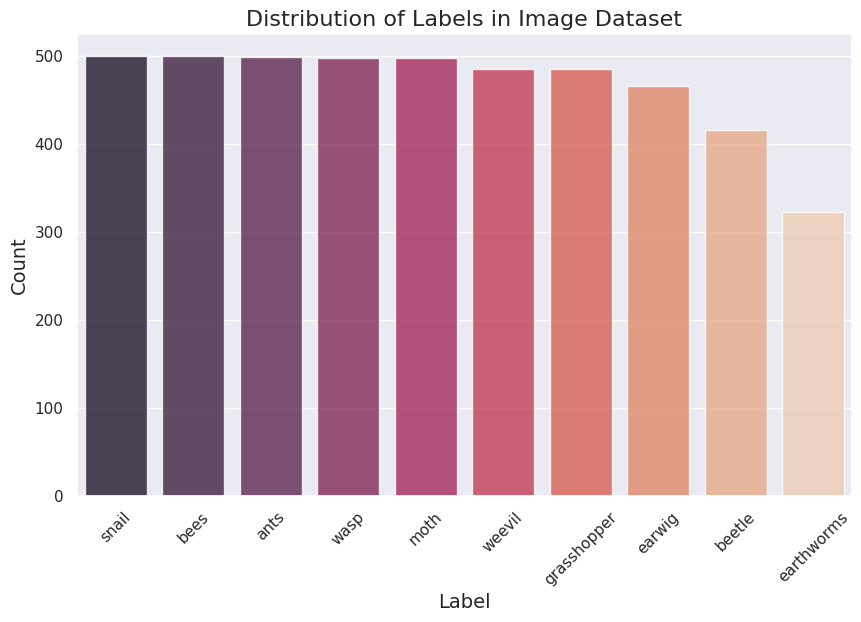

In [18]:
label_counts = image_df['Label'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, alpha=0.8, palette='rocket')
plt.title('Distribution of Labels in Image Dataset', fontsize=16)
plt.xlabel('Label', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45)
plt.show()

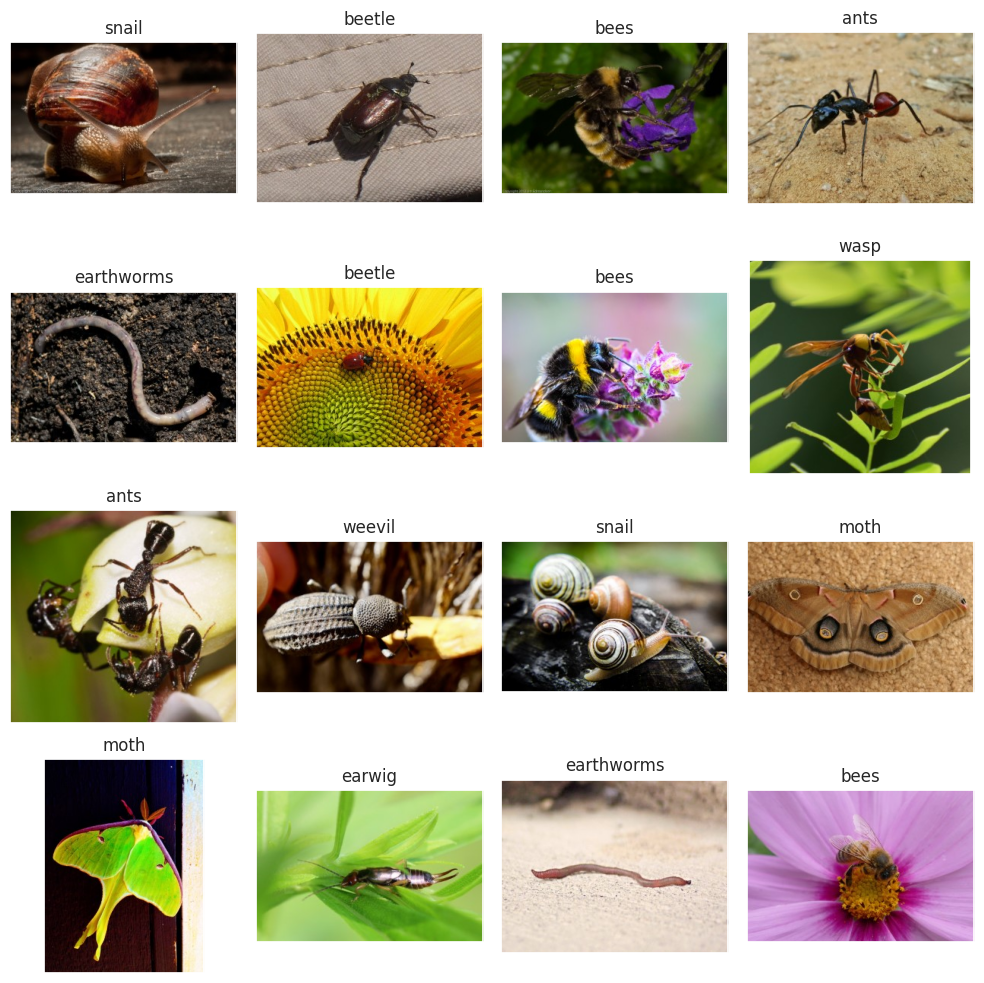

In [19]:
# Display 16 random images from the dataset with their corresponding class labels

# Generate 16 random indices from the dataset
random_index = np.random.randint(0, len(image_df), 16)

# Create a 4x4 grid of subplots with no axis ticks
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10, 10),
                         subplot_kw={'xticks': [], 'yticks': []})

# Loop through each subplot and plot a random image with its label
for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(image_df.Filepath[random_index[i]]))  # Load and display image
    ax.set_title(image_df.Label[random_index[i]])  # Set class label as title

# Adjust layout for better spacing between subplots
plt.tight_layout()
plt.show()  # Display the final image grid


In [20]:
# Separate in train and test data
train_df, test_df = train_test_split(image_df, test_size=0.2, shuffle=True, random_state=42)

In [21]:
# Create an ImageDataGenerator for training and validation sets
# Applies MobileNet preprocessing and reserves 20% of data for validation
train_generator = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,  # Normalize images as required by MobileNetV2
    validation_split=0.2  # Split 20% of the data for validation
)

# Create a separate ImageDataGenerator for the test set
# Applies the same preprocessing without any data augmentation or splitting
test_generator = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input   # Ensure test data is preprocessed the same way
)

In [22]:
# Split the data into three categories.

train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42,
    subset='training'
)

val_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42,
    subset='validation'
)

test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 2988 validated image filenames belonging to 10 classes.
Found 747 validated image filenames belonging to 10 classes.
Found 934 validated image filenames belonging to 10 classes.


In [23]:
# Data Augmentation Pipeline
# This sequential preprocessing layer applies transformations to training images on-the-fly
augment = tf.keras.Sequential([
    # Resize all input images to 224x224
    tf.keras.layers.Resizing(224, 224),

    # Normalize pixel values to the range [0, 1]
    tf.keras.layers.Rescaling(1./255),

    # Randomly flip images horizontally (e.g., mirror images of insects)
    tf.keras.layers.RandomFlip("horizontal"),

    # Apply small random rotations (±10%) to improve rotation invariance
    tf.keras.layers.RandomRotation(0.1),

    # Apply slight random zoom to make the model more robust to scale changes
    tf.keras.layers.RandomZoom(0.1),

    # Randomly adjust image contrast to improve generalization to lighting conditions
    tf.keras.layers.RandomContrast(0.1),
])

In [24]:
# Load the pretrained MobileNetV2 model from TensorFlow applications
pretrained_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),  # Define the expected input image size
    include_top=False,          # Exclude the final classification layer (we'll add our own)
    weights='imagenet',         # Load pretrained weights from ImageNet
    pooling='max'               # Apply global max pooling after the last conv layer
)

# Freeze the base model so its weights won't be updated during training
# Only the custom classification head will be trainable
pretrained_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [25]:
# Create checkpoint callback with .weights.h5 extension
checkpoint_path = "pests_cats_classification_model_checkpoint.weights.h5"
checkpoint_callback = ModelCheckpoint(
    checkpoint_path,
    save_weights_only=True,  # Save only the weights, not the entire model
    monitor="val_accuracy",  # Monitor validation accuracy during training
    save_best_only=True  # Save only the best model weights based on validation accuracy
)

In [26]:
# Setup EarlyStopping callback to stop training if model's val_loss doesn't improve for 3 epochs
early_stopping = EarlyStopping(monitor = "val_loss", # watch the val loss metric
                               patience = 5,
                               restore_best_weights = True) # if val loss decreases for 3 epochs in a row, stop training

In [27]:
# Use the input layer from the pretrained base model
inputs = pretrained_model.input

# Apply data augmentation to the input images
x = augment(inputs)

# Add a dense layer with 128 units and ReLU activation on top of the pretrained model
x = Dense(128, activation='relu')(pretrained_model.output)
x = Dropout(0.45)(x)  # Apply dropout for regularization to prevent overfitting

# Add another dense layer with 256 units and ReLU activation
x = Dense(256, activation='relu')(x)
x = Dropout(0.45)(x)  # Another dropout layer for robustness

# Final output layer with 12 units (for 12 classes) and softmax activation for multiclass classification
outputs = Dense(10, activation='softmax')(x)

# Define the full model combining the pretrained base and custom head
model = Model(inputs=inputs, outputs=outputs)

# Compile the model with a low learning rate and appropriate loss and metric for classification
model.compile(
    optimizer=Adam(0.001),  # Lower learning rate for fine-tuning
    loss='categorical_crossentropy',  # Suitable for multi-class classification
    metrics=['accuracy']  # Monitor accuracy during training
)

# Train the model
history = model.fit(
    train_images,  # Training data
    validation_data=val_images,  # Validation data
    epochs=100,  # Total number of training epochs
    callbacks=[
        early_stopping,
        create_tensorboard_callback("training_logs", "pests_cats_classification"),  # Log training for TensorBoard
        checkpoint_callback,  # Save the best model weights during training
    ]
)

Saving TensorBoard log files to: training_logs/pests_cats_classification/20260825-153727
Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 68s 525ms/step - accuracy: 0.4083 - loss: 1.9383 - val_accuracy: 0.7256 - val_loss: 0.8558
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.6372 - loss: 1.0307 - val_accuracy: 0.8126 - val_loss: 0.6136
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.7242 - loss: 0.8443 - val_accuracy: 0.8353 - val_loss: 0.5011
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.7544 - loss: 0.7257 - val_accuracy: 0.8568 - val_loss: 0.4855
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.7784 - loss: 0.6712 - val_accuracy: 0.8501 - val_loss: 0.4582
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.7875 - loss: 0.6189 - val_accuracy: 0.8876 - val_loss: 0.3721
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.8286 - loss: 0.5184 - val_accuracy: 0.8969 - val_loss: 0.3369
Epoch 8/100
9

In [28]:
results = model.evaluate(test_images, verbose=0)

print("    Test Loss: {:.5f}".format(results[0]))
print("Test Accuracy: {:.2f}%".format(results[1] * 100))

    Test Loss: 0.31955
Test Accuracy: 90.04%


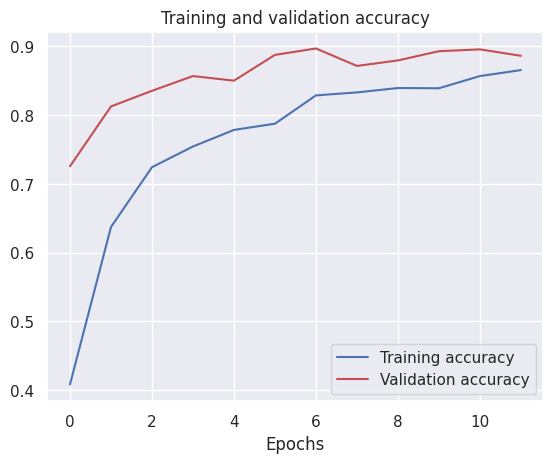

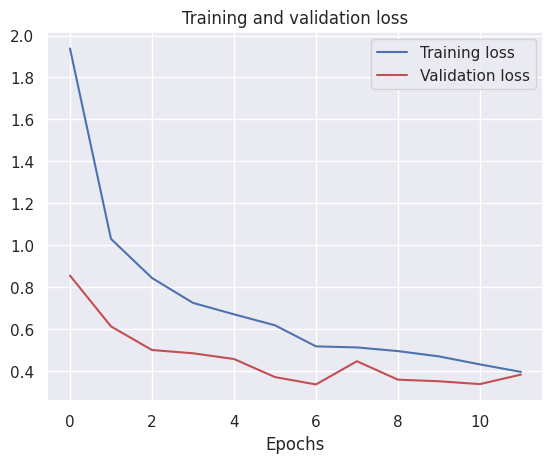

In [29]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'b', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'r', label='Validation accuracy')
plt.xlabel('Epochs')

plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.xlabel('Epochs')

plt.title('Training and validation loss')
plt.legend()
plt.show()

In [30]:
# Predict the label of the test_images
pred = model.predict(test_images)
pred = np.argmax(pred,axis=1)

# Map the label
labels = (train_images.class_indices)
labels = dict((v,k) for k,v in labels.items())
pred = [labels[k] for k in pred]

# Display the result
print(f'The first 5 predictions: {pred[:5]}')

30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 220ms/step
The first 5 predictions: ['wasp', 'earthworms', 'earwig', 'weevil', 'earthworms']


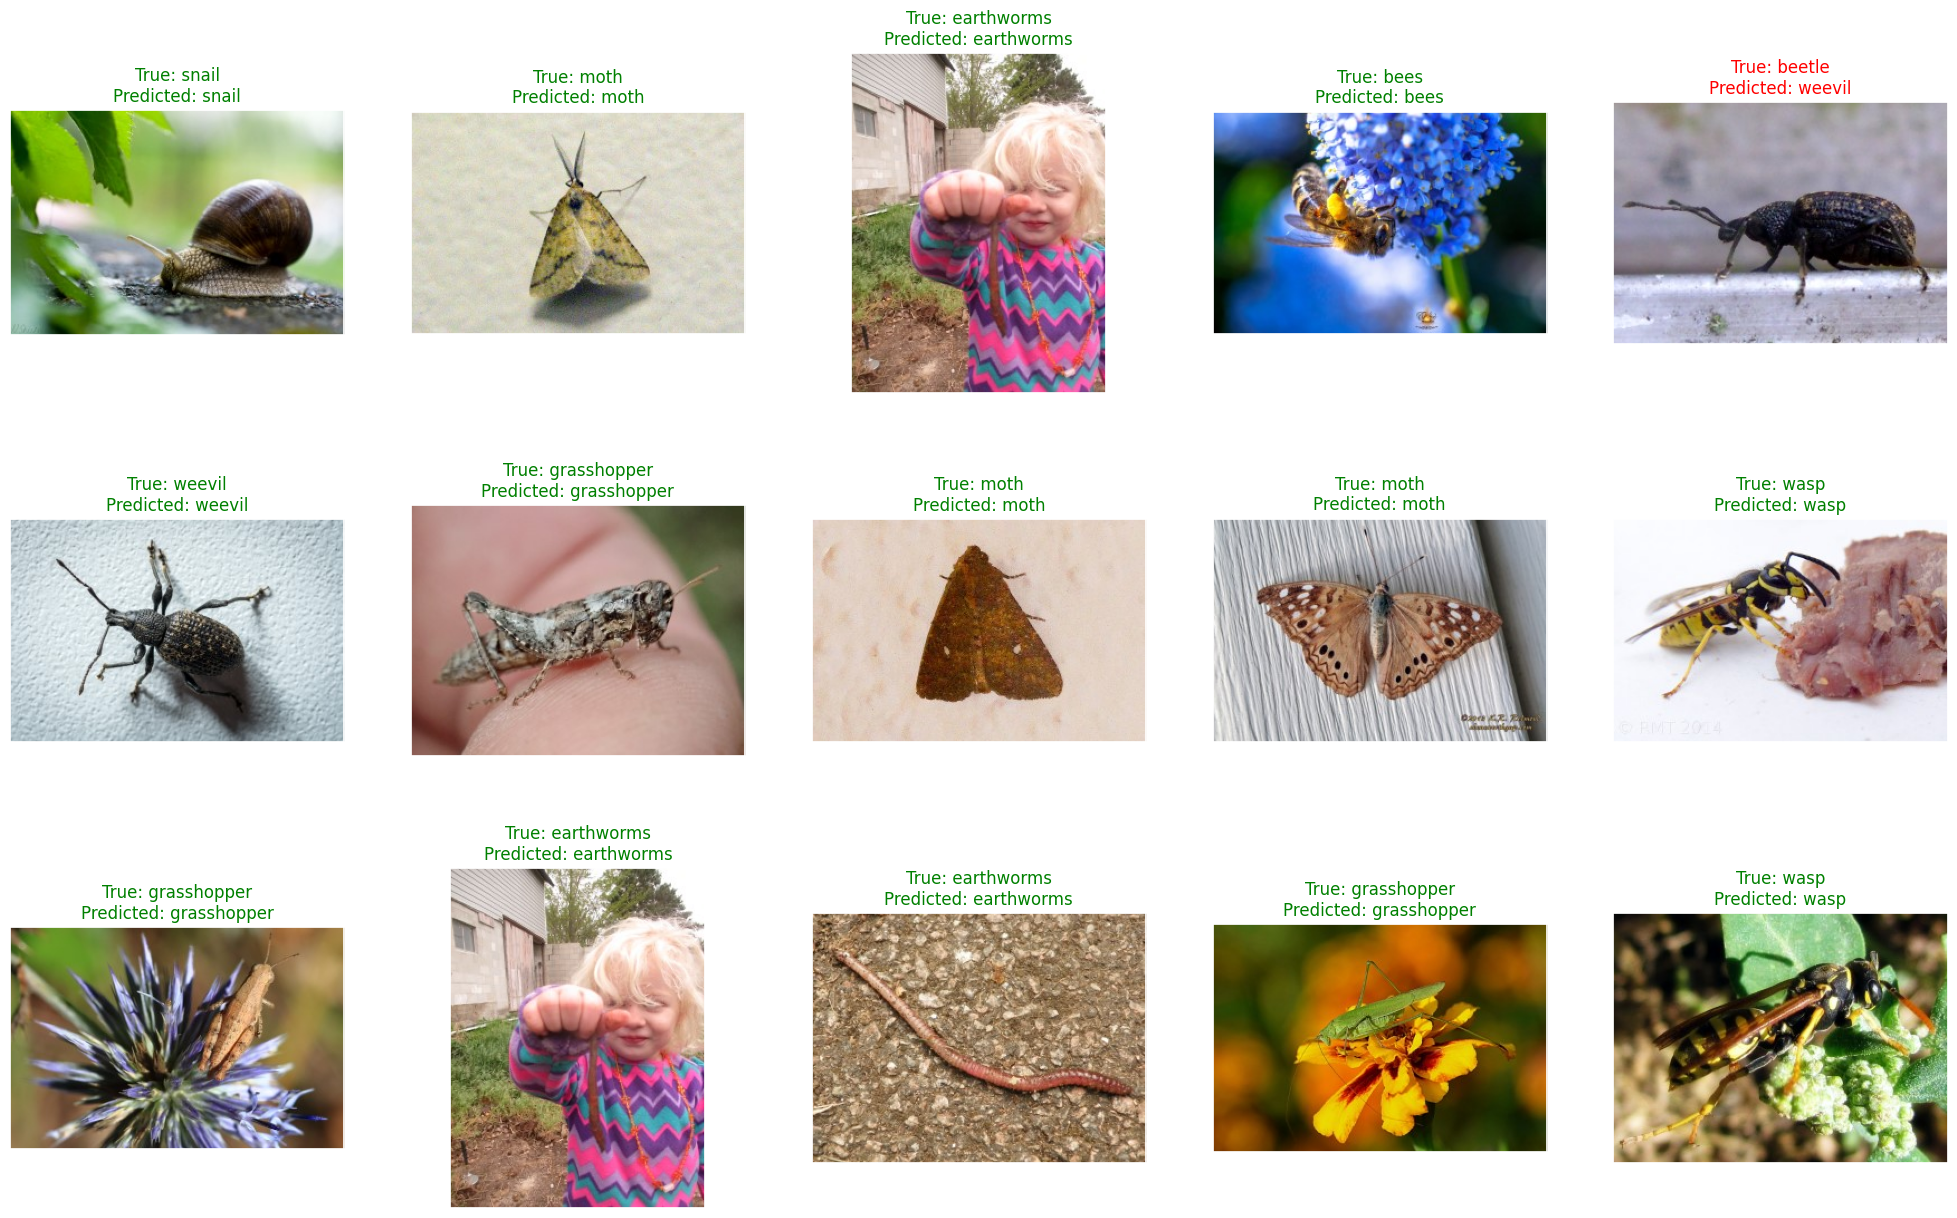

<Figure size 640x480 with 0 Axes>

In [31]:
# Display 15 random pictures from the dataset with their labels
random_index = np.random.randint(0, len(test_df) - 1, 15)
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(25, 15),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(test_df.Filepath.iloc[random_index[i]]))
    if test_df.Label.iloc[random_index[i]] == pred[random_index[i]]:
        color = "green"
    else:
        color = "red"
    ax.set_title(f"True: {test_df.Label.iloc[random_index[i]]}\nPredicted: {pred[random_index[i]]}", color=color)
plt.show()
plt.tight_layout()

In [32]:
y_test = list(test_df.Label)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

        ants       0.98      0.92      0.95       114
        bees       0.90      0.94      0.92        97
      beetle       0.74      0.59      0.66        71
  earthworms       0.90      0.96      0.93        74
      earwig       0.79      0.76      0.77       101
 grasshopper       0.91      0.91      0.91        97
        moth       0.96      0.99      0.97        86
       snail       0.99      0.99      0.99        94
        wasp       0.87      0.92      0.90        93
      weevil       0.91      0.96      0.94       107

    accuracy                           0.90       934
   macro avg       0.89      0.89      0.89       934
weighted avg       0.90      0.90      0.90       934



In [33]:
"""report = classification_report(y_test, pred, output_dict=True)
df = pd.DataFrame(report).transpose()
df"""

'report = classification_report(y_test, pred, output_dict=True)\ndf = pd.DataFrame(report).transpose()\ndf'

In [34]:
def make_confusion_matrix(y_true, y_pred, classes=None, figsize=(15, 7), text_size=10, norm=False, savefig=False):
    """Makes a labelled confusion matrix comparing predictions and ground truth labels.

    If classes is passed, confusion matrix will be labelled, if not, integer class values
  will be used.

  Args:
    y_true: Array of truth labels (must be same shape as y_pred).
    y_pred: Array of predicted labels (must be same shape as y_true).
    classes: Array of class labels (e.g. string form). If `None`, integer labels are used.
    figsize: Size of output figure (default=(10, 10)).
    text_size: Size of output figure text (default=15).
    norm: normalize values or not (default=False).
    savefig: save confusion matrix to file (default=False).

  Returns:
    A labelled confusion matrix plot comparing y_true and y_pred.

  Example usage:
    make_confusion_matrix(y_true=test_labels, # ground truth test labels
                          y_pred=y_preds, # predicted labels
                          classes=class_names, # array of class label names
                          figsize=(15, 15),
                          text_size=10)
    """
  # Create the confustion matrix
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] # normalize it
    n_classes = cm.shape[0] # find the number of classes we're dealing with

    # Plot the figure and make it pretty
    fig, ax = plt.subplots(figsize=figsize)
    cax = ax.matshow(cm, cmap=plt.cm.Blues) # colors will represent how 'correct' a class is, darker == better
    fig.colorbar(cax)

    # Are there a list of classes?
    if classes:
        labels = classes
    else:
        labels = np.arange(cm.shape[0])

    # Label the axes
    ax.set(title="Confusion Matrix",
         xlabel="Predicted label",
         ylabel="True label",
         xticks=np.arange(n_classes), # create enough axis slots for each class
         yticks=np.arange(n_classes),
         xticklabels=labels, # axes will labeled with class names (if they exist) or ints
         yticklabels=labels)

    # Make x-axis labels appear on bottom
    ax.xaxis.set_label_position("bottom")
    ax.xaxis.tick_bottom()
    ### Added: Rotate xticks for readability & increase font size (required due to such a large confusion matrix)
    plt.xticks(rotation=90, fontsize=text_size)
    plt.yticks(fontsize=text_size)

    # Set the threshold for different colors
    threshold = (cm.max() + cm.min()) / 2.

    # Plot the text on each cell
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if norm:
            plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
                horizontalalignment="center",
                color="white" if cm[i, j] > threshold else "black",
                size=text_size)
        else:
            plt.text(j, i, f"{cm[i, j]}",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)

  # Save the figure to the current working directory
    if savefig:
        fig.savefig("confusion_matrix.png")


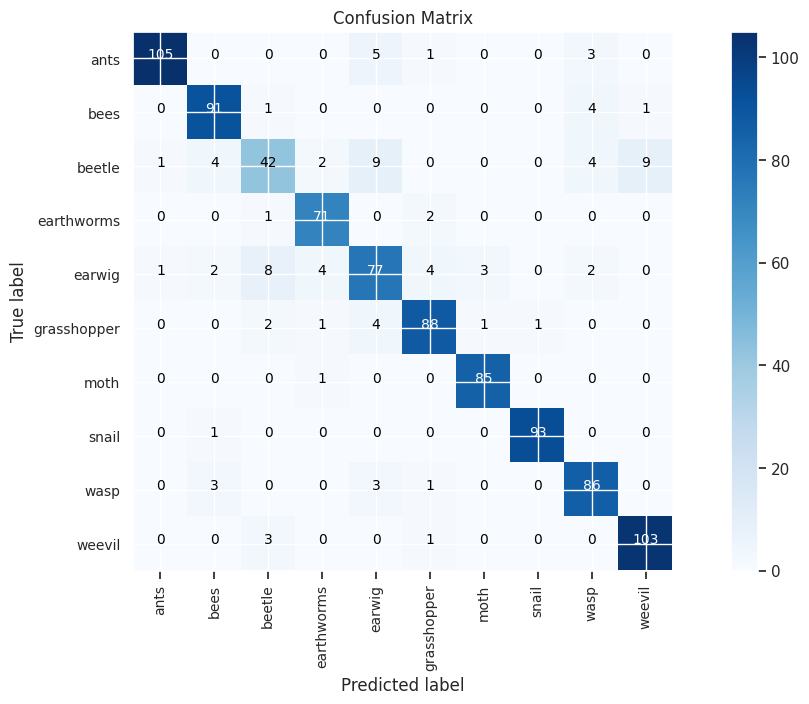

In [35]:
make_confusion_matrix(y_test, pred, list(labels.values()))

In [36]:
# 🟥 Add emoji to harmfulness levels
def color_code_harmfulness(level):
    if level == "Harmful":
        return "🟥 Harmful"
    elif level == "Moderate":
        return "🟨 Moderate"
    elif level == "Neutral":
        return "🟦 Neutral"
    elif level == "Mixed":
        return "🟧 Mixed"
    elif level == "Beneficial":
        return "🟩 Beneficial"
    else:
        return "❓ Unknown"

# 📋 Build prediction-based summary table
summary_data = []
for idx in random_index:
    predicted_label = pred[idx]
    advice = insect_action_guide.get(predicted_label, {})
    harmfulness = advice.get("harmfulness", "Unknown")

    summary_data.append({
        "Image": os.path.basename(test_df.Filepath.iloc[idx]),
        "Predicted Label": predicted_label,
        "Harmfulness": color_code_harmfulness(harmfulness),
        "Action Recommendation": advice.get("recommendation", "No recommendation available.")
    })

df_summary = pd.DataFrame(summary_data)

# 🎨 Format harmfulness with colored HTML
def format_harmfulness_html(level):
    if "Harmful" in level:
        return '<span style="color: red; font-weight: bold;">🟥 Harmful</span>'
    elif "Moderate" in level:
        return '<span style="color: orange; font-weight: bold;">🟨 Moderate</span>'
    elif "Neutral" in level:
        return '<span style="color: blue; font-weight: bold;">🟦 Neutral</span>'
    elif "Beneficial" in level:
        return '<span style="color: green; font-weight: bold;">🟩 Beneficial</span>'
    elif "Mixed" in level:
        return '<span style="color: purple; font-weight: bold;">🟧 Mixed</span>'
    else:
        return '<span style="color: gray;">❓ Unknown</span>'

df_summary["Harmfulness"] = df_summary["Harmfulness"].apply(format_harmfulness_html)

# 💡 Render as HTML-styled table
def render_html_table(df):
    styles = """
    <style>
    table {
        font-size: 16px;
        font-family: Verdana;
        border-collapse: collapse;
        width: 100%;
    }
    th {
        background-color: #f2f2f2;
        padding: 10px;
    }
    td {
        padding: 8px;
        vertical-align: top;
    }
    </style>
    """
    return HTML(styles + df.to_html(escape=False, index=False))

# ✅ Display final table (Predicted Label only — practical use case)
render_html_table(df_summary)

Image,Predicted Label,Harmfulness,Action Recommendation
snail (139).jpg,snail,🟨 Moderate,Hand-pick or use eco-friendly traps.
moth (280).jpg,moth,🟨 Moderate,Monitor regularly; use pheromone traps if needed.
earthworms (286).jpg,earthworms,🟩 Beneficial,No action needed. They improve soil health.
bees (410).jpg,bees,🟩 Beneficial,No action needed. Bees support pollination.
beetle (205).jpg,weevil,🟥 Harmful,Apply crop rotation and use insecticides where necessary.
Weevil (439).jpg,weevil,🟥 Harmful,Apply crop rotation and use insecticides where necessary.
grasshopper (166).jpg,grasshopper,🟥 Harmful,Use targeted insecticides or encourage natural predators.
moth (385).jpg,moth,🟨 Moderate,Monitor regularly; use pheromone traps if needed.
moth (277).jpg,moth,🟨 Moderate,Monitor regularly; use pheromone traps if needed.
wasp (833).jpg,wasp,🟧 Mixed,Only control if nests are near human activity.


In [37]:
def get_img_array(img_path, size):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=size)
    array = tf.keras.preprocessing.image.img_to_array(img)
    # We add a dimension to transform our array into a "batch"
    # of size "size"
    array = np.expand_dims(array, axis=0)
    return array

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # First, we create a model that maps the input image to the activations
    # of the last conv layer as well as the output predictions
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Then, we compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    # This is the gradient of the output neuron (top predicted or chosen)
    # with regard to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient
    # over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array
    # by "how important this channel is" with regard to the top predicted class
    # then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, we will also normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def save_and_display_gradcam(img_path, heatmap, cam_path="cam.jpg", alpha=0.4):
    # Load the original image
    img = tf.keras.preprocessing.image.load_img(img_path)
    img = tf.keras.preprocessing.image.img_to_array(img)

    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = cm.get_cmap("jet")

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)
    # Save the superimposed image
    superimposed_img.save(cam_path)

    # Display Grad CAM
#   display(Image(cam_path))

    return cam_path

# Updated for MobileNetV2
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
decode_predictions = tf.keras.applications.mobilenet_v2.decode_predictions

# "Conv_1" is the standard last convolutional layer name in MobileNetV2
last_conv_layer_name = "Conv_1"
img_size = (224, 224, 3)

# Remove last layer's softmax
model.layers[-1].activation = None

/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/tmp/ipykernel_543/631469424.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


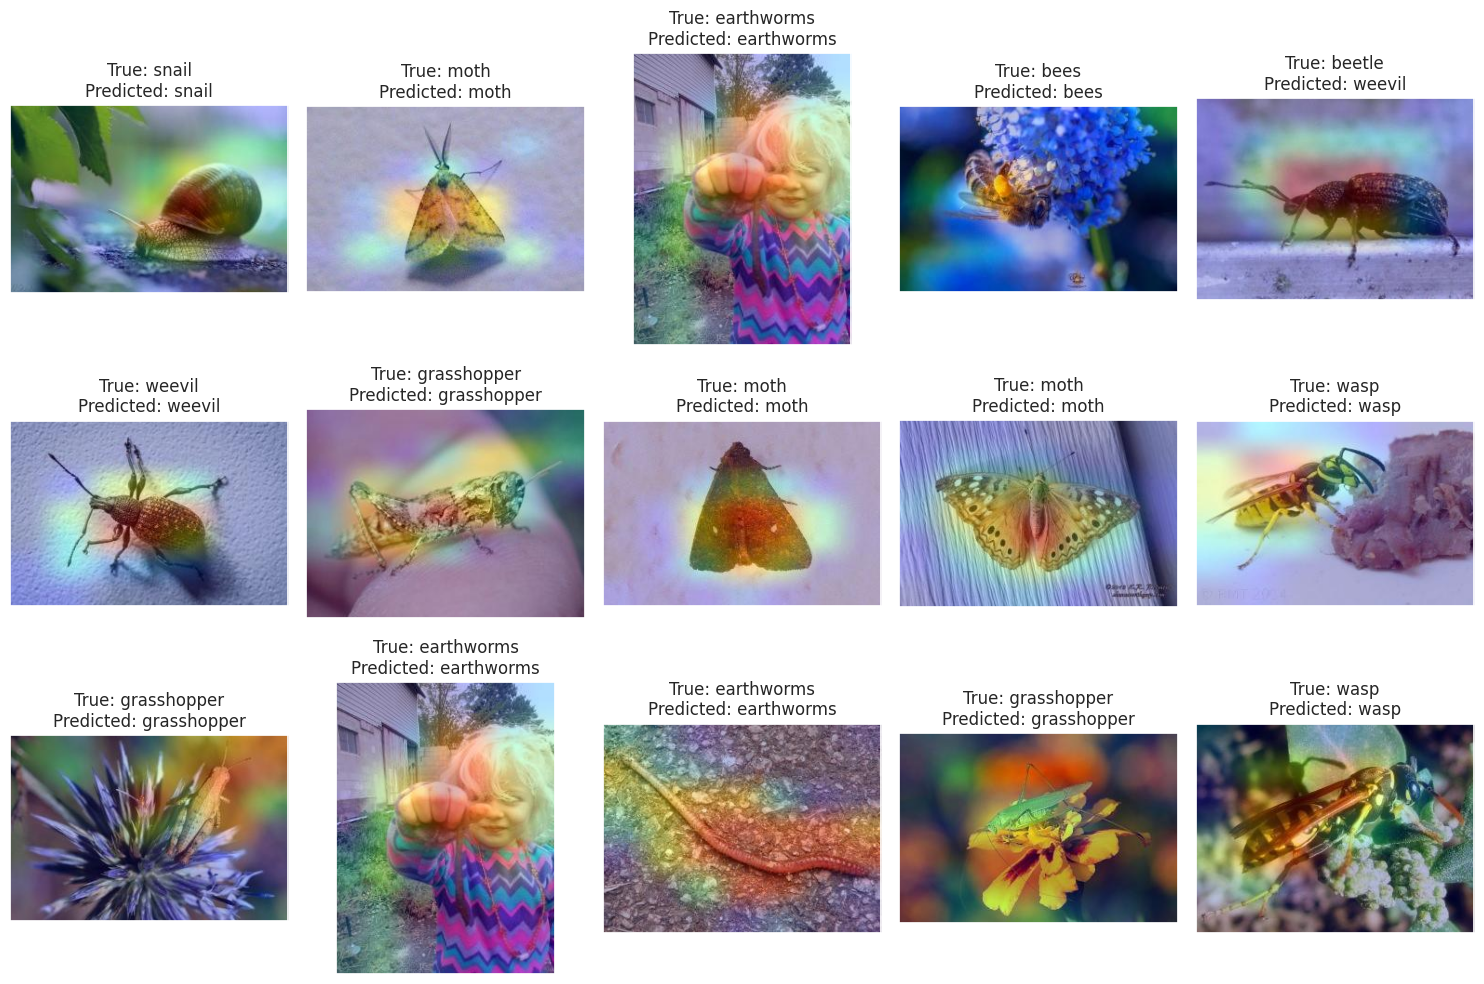

In [38]:
# Display the part of the pictures used by the neural network to classify the pictures
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(15, 10),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    img_path = test_df.Filepath.iloc[random_index[i]]
    img_array = preprocess_input(get_img_array(img_path, size=img_size))
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
    cam_path = save_and_display_gradcam(img_path, heatmap)
    ax.imshow(plt.imread(cam_path))
    ax.set_title(f"True: {test_df.Label.iloc[random_index[i]]}\nPredicted: {pred[random_index[i]]}")
plt.tight_layout()
plt.show()